# Performance: PyTorch, ThermoPack, NeqSim, and teqp

This experiment measures the optimized native GERG-2008 and CPA paths. It
answers four distinct questions:

1. What is the warmed latency of one homogeneous Helmholtz/CPA state?
2. How much does `torch.compile` reduce PyTorch dispatcher overhead?
3. Does native batching recover throughput for reactive-transport-size state
   arrays?
4. When do CPU threads or a GPU help?

Cold construction, compilation, warmed scalar latency, and batched throughput
are reported separately. Timings are hardware-specific observations, not
universal package guarantees. GERG uses the same H2/CH4 coefficient set in
torch-flash, teqp, and ThermoPack. CPA timing uses the same component family,
but cross-association defaults differ between packages; CPA timings therefore
compare workload classes rather than claiming identical parameterization.

Sources:

- `torch.compile` and TorchInductor:
  <https://docs.pytorch.org/docs/stable/generated/torch.compile.html>
- PyTorch CPU intra-operation threads:
  <https://docs.pytorch.org/docs/stable/generated/torch.set_num_threads.html>
- GERG-2008: Kunz and Wagner, *J. Chem. Eng. Data* 57 (2012), 3032--3091,
  <https://doi.org/10.1021/je300655b>
- CPA: Kontogeorgis et al., *Ind. Eng. Chem. Res.* 35 (1996), 4310--4318,
  <https://doi.org/10.1021/ie9600203>
- ThermoPack Python interface:
  <https://thermotools.github.io/thermopack/vcurrent/getting_started.html>
- teqp design and API:
  <https://pages.nist.gov/teqp-docs/en/main/getting_started/index.html>
- NeqSim: <https://github.com/equinor/neqsim-python>

In [1]:
from __future__ import annotations

import gc
import json
import os
import platform
import subprocess
import sys
from importlib.metadata import version
from statistics import median
from timeit import repeat

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

os.environ.setdefault(
    "NEQSIM_JVM_ARGS",
    "-Xmx512m --enable-native-access=ALL-UNNAMED",
)

from thermopack.cpa import SRK_CPA
from thermopack.multiparameter import multiparam

from torch_flash.backends import TeqpBackend
from torch_flash.eos import gerg2008
from torch_flash.eos.cpa import cpa_folas_2005

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")

hardware = pd.Series(
    {
        "platform": platform.platform(),
        "machine": platform.machine(),
        "logical CPUs": os.cpu_count(),
        "PyTorch intra-op threads": torch.get_num_threads(),
        "PyTorch inter-op threads": torch.get_num_interop_threads(),
        "CUDA available": torch.cuda.is_available(),
        "MPS available": torch.backends.mps.is_available(),
    },
    name="value",
)
packages = pd.Series(
    {
        package: version(package)
        for package in ("torch", "torch-flash", "teqp", "thermopack", "neqsim")
    },
    name="version",
)
display(hardware.to_frame())
display(packages.to_frame())

# Run thread-count trials in fresh processes before the main process creates
# any Inductor graphs. The results are plotted in the dedicated section below.
thread_script = r"""
import json
import os
import statistics
import time
import torch
from torch_flash.eos import gerg2008

threads = int(os.environ["TORCH_FLASH_BENCH_THREADS"])
torch.set_num_threads(threads)
model = gerg2008(("hydrogen", "methane"))
states = 4096
temperature = torch.linspace(250.0, 350.0, states, dtype=torch.float64)
density = torch.linspace(100.0, 5000.0, states, dtype=torch.float64)
composition = torch.tensor([0.4, 0.6], dtype=torch.float64).expand(states, -1)
def evaluate():
    return model.pressure(temperature, density.reciprocal(), composition)
for _ in range(5):
    evaluate()
samples = []
for _ in range(20):
    started = time.perf_counter()
    evaluate()
    samples.append(time.perf_counter() - started)
print(json.dumps({"threads": threads, "seconds": statistics.median(samples)}))
"""

available_threads = max(1, os.cpu_count() or 1)
thread_counts = sorted({1, 2, 4, min(8, available_threads), available_threads})
thread_rows = []
for thread_count in thread_counts:
    environment = os.environ.copy()
    environment["TORCH_FLASH_BENCH_THREADS"] = str(thread_count)
    result = subprocess.run(
        [sys.executable, "-c", thread_script],
        check=True,
        capture_output=True,
        text=True,
        env=environment,
    )
    thread_rows.append(json.loads(result.stdout.strip().splitlines()[-1]))
thread_scaling = pd.DataFrame(thread_rows)
thread_scaling["speedup vs one thread"] = (
    thread_scaling.loc[thread_scaling["threads"] == 1, "seconds"].iloc[0]
    / thread_scaling["seconds"]
)

batch_script = r"""
import json
import statistics
import time
import torch
from torch_flash.eos import gerg2008

torch.set_default_dtype(torch.float64)
model = gerg2008(("hydrogen", "methane"))
records = []
for states in (1, 16, 256, 1010):
    temperature = torch.linspace(300.0, 400.0, states)
    pressure = torch.linspace(1.0e4, 100.0e6, states)
    hydrogen = torch.linspace(0.1, 0.9, states)
    composition = torch.stack((hydrogen, 1.0 - hydrogen), dim=-1)
    def evaluate():
        return model.molar_volume(temperature, pressure, composition, "vapor")
    evaluate()
    evaluate()
    samples = []
    for _ in range(5):
        started = time.perf_counter()
        volume = evaluate()
        samples.append(time.perf_counter() - started)
    seconds = statistics.median(samples)
    residual = float(
        ((model.pressure(temperature, volume, composition) - pressure) / pressure)
        .abs()
        .max()
    )
    records.append({
        "states": states,
        "wall time / s": seconds,
        "states / s": states / seconds,
        "maximum |pressure residual|": residual,
    })
print(json.dumps(records))
"""
batch_run = subprocess.run(
    [sys.executable, "-c", batch_script],
    check=True,
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)
batch_records = json.loads(batch_run.stdout.strip().splitlines()[-1])

device_script = r"""
import json
import statistics
import time
import torch
from torch_flash.eos import gerg2008

states = 4096
temperature64 = torch.linspace(250.0, 350.0, states, dtype=torch.float64)
density64 = torch.linspace(100.0, 5000.0, states, dtype=torch.float64)
composition64 = torch.tensor([0.4, 0.6], dtype=torch.float64).expand(states, -1)
cpu_model = gerg2008(("hydrogen", "methane"), dtype=torch.float64)
def cpu_evaluate():
    return cpu_model.pressure(temperature64, density64.reciprocal(), composition64)
for _ in range(5):
    cpu_evaluate()
samples = []
for _ in range(20):
    started = time.perf_counter()
    cpu_evaluate()
    samples.append(time.perf_counter() - started)
print(json.dumps([{
    "device": "CPU float64",
    "milliseconds": 1.0e3 * statistics.median(samples),
    "max relative deviation vs CPU float64": 0.0,
    "scientifically matched precision": True,
}]))
"""
device_run = subprocess.run(
    [sys.executable, "-c", device_script],
    check=True,
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)
device_rows = json.loads(device_run.stdout.strip().splitlines()[-1])

accelerator_script = r"""
import json
import statistics
import time
import torch
from torch_flash.eos import gerg2008

states = 4096
temperature64 = torch.linspace(250.0, 350.0, states, dtype=torch.float64)
density64 = torch.linspace(100.0, 5000.0, states, dtype=torch.float64)
composition64 = torch.tensor([0.4, 0.6], dtype=torch.float64).expand(states, -1)
cpu_model = gerg2008(("hydrogen", "methane"), dtype=torch.float64)
reference = cpu_model.pressure(temperature64, density64.reciprocal(), composition64)
rows = []
if torch.cuda.is_available():
    model = gerg2008(("hydrogen", "methane"), dtype=torch.float64, device="cuda")
    temperature = temperature64.cuda()
    density = density64.cuda()
    composition = composition64.cuda()
    def evaluate():
        return model.pressure(temperature, density.reciprocal(), composition)
    for _ in range(5):
        evaluate()
    torch.cuda.synchronize()
    samples = []
    for _ in range(20):
        started = time.perf_counter()
        result = evaluate()
        torch.cuda.synchronize()
        samples.append(time.perf_counter() - started)
    result = evaluate().cpu()
    rows.append({
        "device": "CUDA float64",
        "milliseconds": 1.0e3 * statistics.median(samples),
        "max relative deviation vs CPU float64": float(
            ((result - reference) / reference).abs().max()
        ),
        "scientifically matched precision": True,
    })
if torch.backends.mps.is_available():
    try:
        torch.ones(1, dtype=torch.float64, device="mps")
        float64_supported = True
    except (RuntimeError, TypeError):
        float64_supported = False
    rows.append({
        "device": "MPS float64 unavailable",
        "milliseconds": None,
        "max relative deviation vs CPU float64": None,
        "scientifically matched precision": float64_supported,
    })
print(json.dumps(rows))
"""
accelerator_run = subprocess.run(
    [sys.executable, "-c", accelerator_script],
    check=True,
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)
device_rows.extend(json.loads(accelerator_run.stdout.strip().splitlines()[-1]))

neqsim_script = r"""
import json
import statistics
import time
from neqsim.thermo import TPflash, addComponent, fluid

model = fluid("gerg-2008", temperature=300.0, pressure=25.0)
addComponent(model, "hydrogen", 0.4)
addComponent(model, "methane", 0.6)
TPflash(model)
samples = []
for _ in range(35):
    model.setTemperature(300.0)
    model.setPressure(25.0)
    started = time.perf_counter()
    TPflash(model)
    model.getZ()
    samples.append(time.perf_counter() - started)
print(json.dumps({"seconds": statistics.median(samples[5:])}))
"""
neqsim_run = subprocess.run(
    [sys.executable, "-c", neqsim_script],
    check=True,
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)
neqsim_seconds = json.loads(neqsim_run.stdout.strip().splitlines()[-1])["seconds"]

,value
platform,macOS-26.5.2-arm64-arm-64bit
machine,arm64
logical CPUs,14
PyTorch intra-op threads,10
PyTorch inter-op threads,14
CUDA available,False
MPS available,True


,version
torch,2.12.1
torch-flash,0.1.0
teqp,0.23.2
thermopack,2.2.3
neqsim,3.16.0


## Timing protocol

Every latency below is a median of repeated, warmed calls. Device
synchronization is included when relevant. Model/JVM construction is
excluded from warmed calls; `torch.compile` first-call cost is measured
independently. The external libraries do not expose a common switch for
solver tolerances, so TP-root comparisons verify the returned pressure while
retaining each implementation's production solver.

In [2]:
def median_latency(
    function,
    *,
    number: int,
    repetitions: int = 7,
    warmups: int = 5,
    synchronize=None,
) -> float:
    """Return median seconds per call after explicit warmup."""
    for _ in range(warmups):
        function()
    if synchronize is not None:
        synchronize()

    def synchronized_call():
        result = function()
        if synchronize is not None:
            synchronize()
        return result

    return median(repeat(synchronized_call, number=number, repeat=repetitions)) / number

## Exact GERG homogeneous-state kernel

At 300 K, 1000 mol/m3, and x(H2)=0.4, all three implementations reproduce
the same pressure. This makes pressure-kernel latency the cleanest
same-equation comparison. NeqSim's public API is TP-state oriented rather
than a prescribed-density Helmholtz call, so it enters the next comparison.

In [3]:
temperature = torch.tensor(300.0)
molar_density = torch.tensor(1000.0)
molar_volume = molar_density.reciprocal()
composition = torch.tensor([0.4, 0.6])
composition_numpy = composition.numpy()

gerg = gerg2008(("hydrogen", "methane"))
teqp_backend = TeqpBackend.gerg2008(("hydrogen", "methane"))
teqp_model = teqp_backend._model
teqp_gas_constant = teqp_model.get_R(composition_numpy)
thermopack_gerg = multiparam("H2,C1", "GERG2008")


def torch_gerg_pressure():
    return gerg.pressure(temperature, molar_volume, composition)


def teqp_gerg_pressure():
    ar01 = teqp_model.get_Ar01(
        float(temperature),
        float(molar_density),
        composition_numpy,
    )
    return float(molar_density) * teqp_gas_constant * float(temperature) * (1.0 + ar01)


def thermopack_gerg_pressure():
    return thermopack_gerg.pressure_tv(
        float(temperature),
        float(molar_volume),
        composition_numpy,
    )[0]


gerg_compile_script = r"""
import json
import statistics
import time
import torch
from torch_flash.eos import gerg2008

model = gerg2008(("hydrogen", "methane"))
temperature = torch.tensor(300.0, dtype=torch.float64)
volume = torch.tensor(0.001, dtype=torch.float64)
composition = torch.tensor([0.4, 0.6], dtype=torch.float64)
compiled = torch.compile(
    lambda: model.pressure(temperature, volume, composition),
    fullgraph=True,
)
started = time.perf_counter()
value = compiled()
cold = time.perf_counter() - started
for _ in range(5):
    compiled()
samples = []
for _ in range(500):
    started = time.perf_counter()
    compiled()
    samples.append(time.perf_counter() - started)
print(json.dumps({
    "cold": cold,
    "seconds": statistics.median(samples),
    "value": float(value),
}))
"""
gerg_compile_run = subprocess.run(
    [sys.executable, "-c", gerg_compile_script],
    check=True,
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)
gerg_compile_result = json.loads(gerg_compile_run.stdout.strip().splitlines()[-1])
gerg_compile_seconds = gerg_compile_result["cold"]
compiled_pressure_value = gerg_compile_result["value"]

gerg_pressure_values = pd.Series(
    {
        "torch-flash eager": float(torch_gerg_pressure()),
        "torch-flash compiled": float(compiled_pressure_value),
        "ThermoPack": thermopack_gerg_pressure(),
        "teqp": teqp_gerg_pressure(),
    },
    name="pressure / Pa",
)
gerg_pressure_latencies = pd.Series(
    {
        "torch-flash eager": median_latency(torch_gerg_pressure, number=100),
        "torch-flash compiled": gerg_compile_result["seconds"],
        "ThermoPack": median_latency(thermopack_gerg_pressure, number=1000),
        "teqp": median_latency(teqp_gerg_pressure, number=2000),
    },
    name="seconds / state",
)
display(gerg_pressure_values.to_frame())
display((1.0e6 * gerg_pressure_latencies).to_frame("median microseconds / state"))
print(f"GERG compiled first call, including compilation: {gerg_compile_seconds:.3f} s")
assert (
    (gerg_pressure_values - gerg_pressure_values["teqp"]).abs()
    / gerg_pressure_values["teqp"]
).max() < 3.0e-13

,pressure / Pa
torch-flash eager,2.473364e+06
torch-flash compiled,2.473364e+06
ThermoPack,2.473364e+06
teqp,2.473364e+06


,median microseconds / state
torch-flash eager,1105.332919
torch-flash compiled,38.875034
ThermoPack,5.999917
teqp,1.137855


GERG compiled first call, including compilation: 3.375 s


## CPA association kernel

The current site solver uses ten damped Picard updates followed by eight
positivity-limited Newton updates with an analytic mass-action Jacobian, and
evaluates volume-scan grids as a batch. The homogeneous pressure comparison
isolates that intensive association kernel. The robust 96-point scan remains
a fallback for difficult phase-root states.

In [4]:
cpa = cpa_folas_2005(("water", "methanol"))
cpa_temperature = torch.tensor(350.0)
cpa_pressure = torch.tensor(1.0e5)
cpa_composition = torch.tensor([0.5, 0.5])
cpa_volume = torch.tensor(3.05e-5)
thermopack_cpa = SRK_CPA("H2O,MEOH")


def torch_cpa_pressure():
    return cpa.pressure(cpa_temperature, cpa_volume, cpa_composition)


def thermopack_cpa_pressure():
    return thermopack_cpa.pressure_tv(350.0, float(cpa_volume), [0.5, 0.5])[0]


cpa_compile_script = r"""
import json
import statistics
import time
import torch
from torch_flash.eos.cpa import cpa_folas_2005

model = cpa_folas_2005(("water", "methanol"))
temperature = torch.tensor(350.0, dtype=torch.float64)
volume = torch.tensor(3.05e-5, dtype=torch.float64)
composition = torch.tensor([0.5, 0.5], dtype=torch.float64)
compiled = torch.compile(
    lambda: model.pressure(temperature, volume, composition),
    fullgraph=True,
)
started = time.perf_counter()
value = compiled()
cold = time.perf_counter() - started
for _ in range(5):
    compiled()
samples = []
for _ in range(500):
    started = time.perf_counter()
    compiled()
    samples.append(time.perf_counter() - started)
print(json.dumps({
    "cold": cold,
    "seconds": statistics.median(samples),
    "value": float(value),
}))
"""
cpa_compile_run = subprocess.run(
    [sys.executable, "-c", cpa_compile_script],
    check=True,
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)
cpa_compile_result = json.loads(cpa_compile_run.stdout.strip().splitlines()[-1])
cpa_compile_seconds = cpa_compile_result["cold"]
cpa_pressure_latencies = pd.Series(
    {
        "torch-flash eager": median_latency(torch_cpa_pressure, number=100),
        "torch-flash compiled": cpa_compile_result["seconds"],
        "ThermoPack": median_latency(thermopack_cpa_pressure, number=1000),
    },
    name="seconds / state",
)
display((1.0e6 * cpa_pressure_latencies).to_frame("median microseconds / state"))
print(f"CPA compiled first call, including compilation: {cpa_compile_seconds:.3f} s")

,median microseconds / state
torch-flash eager,1089.718749
torch-flash compiled,114.312512
ThermoPack,23.435833


CPA compiled first call, including compilation: 8.973 s


### Scalar homogeneous-kernel plots

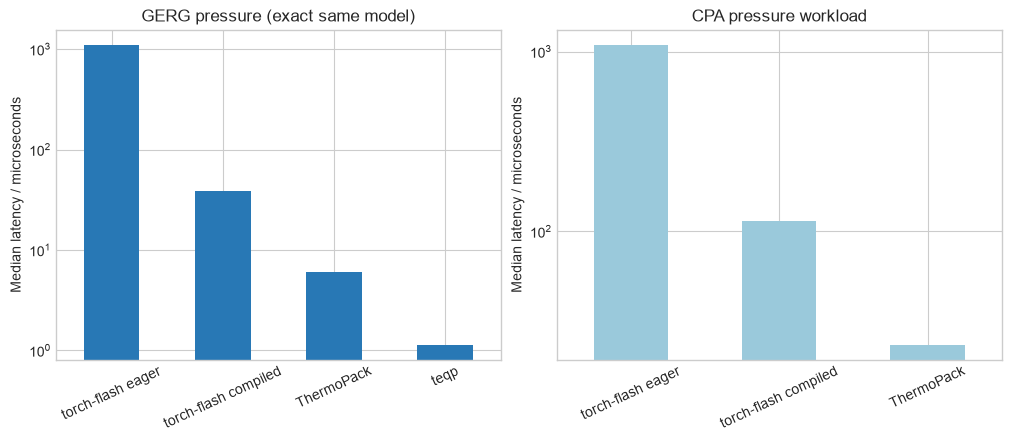

1607

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.3), constrained_layout=True)
(1.0e6 * gerg_pressure_latencies).plot.bar(ax=axes[0], color="#2878B5")
axes[0].set(
    yscale="log",
    ylabel="Median latency / microseconds",
    title="GERG pressure (exact same model)",
)
(1.0e6 * cpa_pressure_latencies).plot.bar(ax=axes[1], color="#9AC9DB")
axes[1].set(
    yscale="log",
    ylabel="Median latency / microseconds",
    title="CPA pressure workload",
)
for axis in axes:
    axis.tick_params(axis="x", rotation=25)
plt.show()

gc.collect()

## GERG TP root: all four packages

This state is single-phase and every implementation returns the same molar
volume. teqp uses an eight-update analytic-density Newton solve based on
`Ar01` and `Ar02`; this avoids timing the deliberately conservative
400-point scan in the validation adapter. NeqSim's JVM is already running
before timing. Its reported call includes setting T/P and performing
`TPflash`, which is somewhat broader work than a single phase root.

In [6]:
target_pressure = torch.tensor(2.5e6)


def torch_gerg_volume():
    return gerg.molar_volume(
        temperature,
        target_pressure,
        composition,
        "vapor",
    )


def thermopack_gerg_volume():
    return thermopack_gerg.specific_volume(
        300.0,
        2.5e6,
        composition_numpy,
        thermopack_gerg.VAPPH,
    )[0]


def teqp_gerg_volume():
    density = 2.5e6 / (teqp_gas_constant * 300.0)
    for _ in range(8):
        ar01 = teqp_model.get_Ar01(300.0, density, composition_numpy)
        ar02 = teqp_model.get_Ar02(300.0, density, composition_numpy)
        pressure_value = density * teqp_gas_constant * 300.0 * (1.0 + ar01)
        pressure_slope = teqp_gas_constant * 300.0 * (1.0 + 2.0 * ar01 + ar02)
        density -= (pressure_value - 2.5e6) / pressure_slope
    return 1.0 / density


gerg_volume_values = pd.Series(
    {
        "torch-flash": float(torch_gerg_volume()),
        "ThermoPack": thermopack_gerg_volume(),
        "teqp": teqp_gerg_volume(),
    },
    name="molar volume / m3 mol-1",
)
gerg_volume_latencies = pd.Series(
    {
        "torch-flash": median_latency(torch_gerg_volume, number=20),
        "ThermoPack": median_latency(thermopack_gerg_volume, number=500),
        "teqp": median_latency(teqp_gerg_volume, number=500),
        "NeqSim TPflash": neqsim_seconds,
    },
    name="seconds / call",
)
display(gerg_volume_values.to_frame())
display((1.0e6 * gerg_volume_latencies).to_frame("median microseconds / call"))
assert (
    (gerg_volume_values - gerg_volume_values["teqp"]).abs() / gerg_volume_values["teqp"]
).max() < 3.0e-11

,molar volume / m3 mol-1
torch-flash,0.000989
ThermoPack,0.000989
teqp,0.000989


,median microseconds / call
torch-flash,13119.245850
ThermoPack,11.708416
teqp,10.481918
NeqSim TPflash,451.562519


## Native GERG batch scaling

The state axis is now native throughout reducing functions, Helmholtz term
evaluation, pressure autodiff, caloric derivatives, and the phase-specific
density solve. The density root first advances one conventional seed for the
complete batch, then applies a multi-seed search only to the failed subset.
Vectorized finite-difference slopes locate each root; when any input or
fitted parameter requires a gradient, one exact Newton correction restores
the implicit derivative.

In [7]:
batch_scaling = pd.DataFrame(batch_records)
display(batch_scaling)
assert batch_scaling["maximum |pressure residual|"].max() < 1.0e-9

,states,wall time / s,states / s,maximum |pressure residual|
0,1,0.039121,25.561392,0.000000e+00
1,16,0.042812,373.723352,1.203537e-15
2,256,0.093040,2751.510880,1.887186e-15
3,1010,0.242813,4159.578892,2.024334e-15


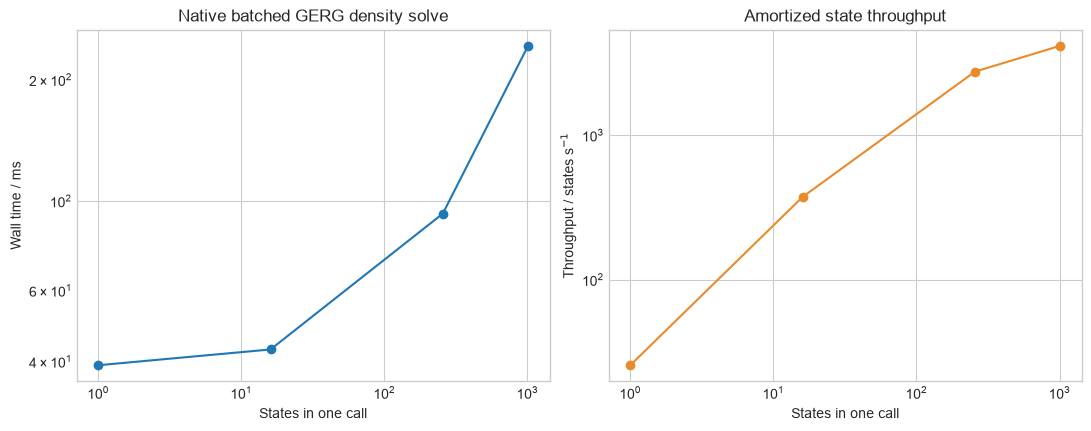

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)
axes[0].plot(
    batch_scaling["states"],
    1.0e3 * batch_scaling["wall time / s"],
    "o-",
)
axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="States in one call",
    ylabel="Wall time / ms",
    title="Native batched GERG density solve",
)
axes[1].plot(
    batch_scaling["states"],
    batch_scaling["states / s"],
    "o-",
    color="#E98B2A",
)
axes[1].set(
    xscale="log",
    yscale="log",
    xlabel="States in one call",
    ylabel="Throughput / states s$^{-1}$",
    title="Amortized state throughput",
)
plt.show()

## CPU thread scaling

Thread counts are benchmarked in fresh Python processes because
`torch.set_num_threads` should be called before eager/JIT/autograd work.
Small scalar kernels do not contain enough work to benefit, whereas a
4096-state GERG pressure batch does. More threads need not be faster once
memory bandwidth and scheduling overhead dominate.

In [9]:
display(thread_scaling)

,threads,seconds,speedup vs one thread
0,1,0.026565,1.000000
1,2,0.017147,1.549247
2,4,0.012767,2.080809
3,8,0.012628,2.103711
4,14,0.013865,1.915987


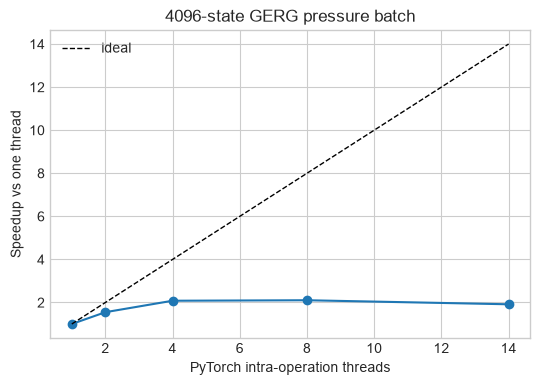

In [10]:
fig, axis = plt.subplots(figsize=(6.2, 4.0))
axis.plot(
    thread_scaling["threads"],
    thread_scaling["speedup vs one thread"],
    "o-",
)
axis.plot(
    thread_scaling["threads"],
    thread_scaling["threads"],
    "k--",
    linewidth=1,
    label="ideal",
)
axis.set(
    xlabel="PyTorch intra-operation threads",
    ylabel="Speedup vs one thread",
    title="4096-state GERG pressure batch",
)
axis.legend()
plt.show()

## GPU and precision boundary

CUDA is benchmarked in float64 when present. The runtime precision probe on
this Apple host rejects MPS float64 tensors. An MPS float32 timing is
deliberately omitted because it would not be an equal-accuracy comparison:
float32 can lose meaningful accuracy near phase boundaries and critical
loci.

In [11]:
device_comparison = pd.DataFrame(device_rows)
display(device_comparison)

,device,milliseconds,max relative deviation vs CPU float64,scientifically matched precision
0,CPU float64,13.211812,0.0,True
1,MPS float64 unavailable,NaN,NaN,False


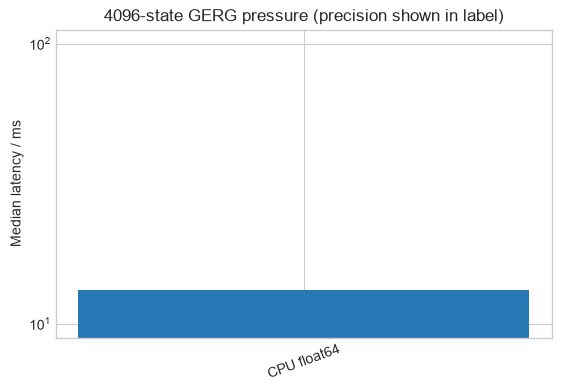

In [12]:
fig, axis = plt.subplots(figsize=(6.4, 4.0))
axis.bar(
    device_comparison["device"],
    device_comparison["milliseconds"],
    color=["#2878B5", "#48A9A6", "#9AC9DB"][: len(device_comparison)],
)
axis.set(
    yscale="log",
    ylabel="Median latency / ms",
    title="4096-state GERG pressure (precision shown in label)",
)
axis.tick_params(axis="x", rotation=20)
plt.show()

## Conclusions

- Compiling repeated homogeneous kernels materially narrows the scalar gap,
  but its multi-second first call must be amortized; it should not be hidden
  inside a one-off flash.
- Native state batching is the largest GERG gain for simulator workloads.
  It removes Python loops while preserving a strict pressure-residual check.
- CPA benefits from both a batched site axis and analytic Newton refinement.
  The robust full root scan remains available for stable-root selection and
  difficult states.
- CPU thread count is a workload parameter, not a package-wide constant.
  The measured plateau should guide deployment on similar hardware.
- CUDA float64 is the intended GPU path for rigorous thermodynamics. MPS is
  excluded from the timing ratio until it can run the same float64 workload.
- ThermoPack and teqp remain substantially faster for one scalar state.
  torch-flash's competitive regime is repeated compiled kernels, batched
  states, gradients, and accelerator-resident workflows.